# Arrow's Impossibility Theorem Through Spatial Voting

This notebook tries to build intuition for Arrow's impossibility theorem using spatial elections. It tries to explain the basic ingredients, and shows some examples where Arrow's theorem holds. It also attempts to show what the theorem does not say.

---
## Imports and setup

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
if (cwd / "configs").exists() and (cwd / "electoral_sim").exists():
    REPO_ROOT = cwd
else:
    REPO_ROOT = cwd.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from electoral_sim.ballots import BallotProfile
from electoral_sim.candidates import fixed_candidates
from electoral_sim.electorate import Electorate
from electoral_sim.social_choice import SocialRanking, borda_social_ranking, plurality_social_ranking
from electoral_sim.utils import (
    check_iia,
    check_non_dictatorship,
    check_unanimity,
    compare_iia,
    plot_electorate,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

SEED = 7

---
## Preliminaries

The spatial setup:

- Each voter has an ideal point \(x_i \in [0,1]^2\).
- Each candidate has a position \(c_j \in [0,1]^2\).
- A voter prefers the candidate who is closer in Euclidean distance.
- Those distances produce a ranking for each voter.

**Social choice rule:** It is a procedure that takes individual voter preferences as input and turns them into a collective outcome. Depending on the setting, that outcome might be a winner or a full social ranking.

A very simple example is plurality voting. If three voters rank the candidates like this:

- voter 1: A > B > C
- voter 2: A > C > B
- voter 3: B > C > A

then plurality only looks at each voter's top choice. A gets two first-place votes, B gets one, and C gets none, so plurality declares A the winner.

**Goal of Arrow's impossibility theorem:** building a rule that works for every possible ranking profile while also satisfying a few very natural conditions.

The three conditions:

- Unanimity (also called Pareto efficiency): if everyone prefers A to B, society should not rank B above A.
- Independence of irrelevant alternatives (IIA): the social choice between A and B should depend only on how voters compare A and B, not on whether some third candidate C is present.
- Non-dictatorship: the social ranking should not always reduce to one special voter's ranking.

## Helper functions

In [3]:
TRIANGLE_CANDIDATES = fixed_candidates(
    [[0.12, 0.12], [0.88, 0.18], [0.42, 0.86]],
    ["A", "B", "C"],
)


# Build a small ranking table that is easy to read inline.
def ranking_frame(ranking):
    ordered_values = [ranking.values[idx] for idx in ranking.candidate_order]
    return pd.DataFrame(
        {
            "rank": np.arange(1, len(ranking.candidate_order) + 1),
            "candidate": ranking.ordered_labels,
            ranking.value_label: ordered_values,
        }
    )


# Convert a candidate order into a simple text string like A > B > C.
def ranking_text(labels):
    return " > ".join(labels)


# Call ranking builders that may or may not use the candidate labels.
def build_ranking(rule, ballots, candidates):
    try:
        return rule(ballots, candidates)
    except TypeError:
        return rule(ballots)


# Keep the non-dictatorship note short and readable in the notebook.
def non_dictatorship_note(report):
    if report.satisfied:
        return report.details
    if len(report.matching_voter_indices) == 1:
        return (
            "Fails on this profile: the social ranking exactly matches "
            f"voter {report.matching_voter_indices[0]}."
        )
    return "Fails on this profile: the social ranking exactly matches at least one voter."


# Summarize which Arrow-style conditions hold for one rule on one profile.
def criterion_table(ballots, candidates, rule):
    ranking = build_ranking(rule, ballots, candidates)
    unanimity = check_unanimity(ballots, ranking, candidates)
    non_dictatorship = check_non_dictatorship(ballots, ranking)
    iia = check_iia(ballots, rule, candidates)

    table = pd.DataFrame(
        {
            "criterion": ["Unanimity", "Non-dictatorship", "IIA"],
            "satisfied_on_this_profile": [
                unanimity.satisfied,
                non_dictatorship.satisfied,
                iia.satisfied,
            ],
            "note": [
                unanimity.details,
                non_dictatorship_note(non_dictatorship),
                iia.details,
            ],
        }
    )
    return ranking, table


# A toy rule that ignores the voters and always ranks candidates A > B > C.
def fixed_priority_ranking(ballots, candidates=None):
    labels = list(candidates.labels if candidates is not None else [f"C{i}" for i in range(ballots.n_candidates)])
    order = list(range(ballots.n_candidates))
    values = np.arange(ballots.n_candidates, 0, -1, dtype=float)
    return SocialRanking(
        method_name="Fixed priority rule",
        candidate_order=order,
        labels=labels,
        values=values,
        value_label="priority",
    )


# A toy rule that simply copies voter 0's ranking.
def dictatorship_rule(ballots, candidates=None):
    labels = list(candidates.labels if candidates is not None else [f"C{i}" for i in range(ballots.n_candidates)])
    dictator_ranking = ballots.active_rankings()[0]
    order = [int(candidate_idx) for candidate_idx in dictator_ranking if candidate_idx >= 0]
    values = np.zeros(ballots.n_candidates, dtype=float)
    for points, candidate_idx in zip(range(ballots.n_candidates, 0, -1), order):
        values[candidate_idx] = float(points)
    return SocialRanking(
        method_name="Dictatorship rule",
        candidate_order=order,
        labels=labels,
        values=values,
        value_label="dictator_points",
    )


# Everybody sits near candidate B, so the voters are unanimous about the ranking.
def make_unanimity_violation_profile(seed=3):
    rng = np.random.default_rng(seed)
    electorate = Electorate(
        np.clip(rng.normal(loc=[0.84, 0.48], scale=[0.015, 0.015], size=(40, 2)), 0.0, 1.0),
        dim_names=["economic", "social"],
    )
    ballots = BallotProfile.from_preferences(electorate, TRIANGLE_CANDIDATES)
    return electorate, TRIANGLE_CANDIDATES, ballots


# A mixed electorate with no unanimous pairwise agreement, used for the dictatorship example.
def make_dictatorship_profile():
    electorate = Electorate(
        np.array(
            [
                [0.30, 0.26],
                [0.84, 0.48],
                [0.26, 0.58],
                [0.66, 0.92],
                [0.70, 0.18],
            ]
        ),
        dim_names=["economic", "social"],
    )
    ballots = BallotProfile.from_preferences(electorate, TRIANGLE_CANDIDATES)
    return electorate, TRIANGLE_CANDIDATES, ballots


# A small profile where Borda flips its view of A versus B when C is removed.
def make_iia_profile():
    electorate = Electorate(
        np.array(
            [
                [0.84, 0.48],
                [0.84, 0.48],
                [0.26, 0.58],
                [0.26, 0.58],
                [0.26, 0.58],
            ]
        ),
        dim_names=["economic", "social"],
    )
    ballots = BallotProfile.from_preferences(electorate, TRIANGLE_CANDIDATES)
    return electorate, TRIANGLE_CANDIDATES, ballots


SPOILER_CANDIDATES = fixed_candidates(
    [[0.30, 0.50], [0.80, 0.50], [0.42, 0.52]],
    ["Left", "Right", "Left-Spoiler"],
)


# A classic spoiler-style plurality profile: the left lane splits and the right lane benefits.
def make_plurality_spoiler_profile():
    electorate = Electorate(
        np.array(
            [
                [0.28, 0.49],
                [0.31, 0.52],
                [0.29, 0.51],
                [0.43, 0.51],
                [0.41, 0.53],
                [0.44, 0.50],
                [0.79, 0.49],
                [0.81, 0.52],
                [0.78, 0.51],
                [0.82, 0.48],
            ]
        ),
        dim_names=["economic", "social"],
    )
    ballots = BallotProfile.from_preferences(electorate, SPOILER_CANDIDATES)
    return electorate, SPOILER_CANDIDATES, ballots


CROWDED_LANE_CANDIDATES = fixed_candidates(
    [[0.20, 0.55], [0.82, 0.50], [0.48, 0.62], [0.50, 0.38]],
    ["Left", "Right", "Moderate-A", "Moderate-B"],
)


# A crowded-field plurality profile: two moderate candidates split one lane.
def make_crowded_lane_profile():
    electorate = Electorate(
        np.array(
            [
                [0.47, 0.63],
                [0.49, 0.60],
                [0.46, 0.65],
                [0.49, 0.36],
                [0.52, 0.39],
                [0.50, 0.41],
                [0.81, 0.51],
                [0.83, 0.49],
                [0.78, 0.44],
                [0.84, 0.50],
            ]
        ),
        dim_names=["economic", "social"],
    )
    ballots = BallotProfile.from_preferences(electorate, CROWDED_LANE_CANDIDATES)
    return electorate, CROWDED_LANE_CANDIDATES, ballots


REASONABLE_CASE_CANDIDATES = fixed_candidates(
    [[0.18, 0.50], [0.50, 0.50], [0.82, 0.50], [0.36, 0.62]],
    ["Left", "Center", "Right", "Center-Left"],
)


# A structured electorate where Borda violates IIA, but still picks a broadly sensible center winner.
def make_reasonable_borda_profile():
    electorate = Electorate(
        np.array(
            [
                [0.16, 0.50],
                [0.16, 0.50],
                [0.16, 0.50],
                [0.50, 0.50],
                [0.62, 0.52],
                [0.70, 0.50],
            ]
        ),
        dim_names=["economic", "social"],
    )
    ballots = BallotProfile.from_preferences(electorate, REASONABLE_CASE_CANDIDATES)
    return electorate, REASONABLE_CASE_CANDIDATES, ballots

---
## Case study 1: Unanimity failure

The first rule is intentionally simple in a comical way. It ignores the voters and always ranks the candidates as A > B > C.

The electorate in this simulation is clustered near candidate B, so all voters end up sharing the same ranking. That makes it easy to see whether the rule is respecting unanimous agreement or not.

,item,value
0,shared voter ranking,B > C > A
1,social ranking produced by the rule,A > B > C


,criterion,satisfied_on_this_profile,note
0,Unanimity,False,The social ranking violates unanimous voter pr...
1,Non-dictatorship,True,No active voter's full pairwise ordering match...
2,IIA,True,No IIA violations were found in the searched c...


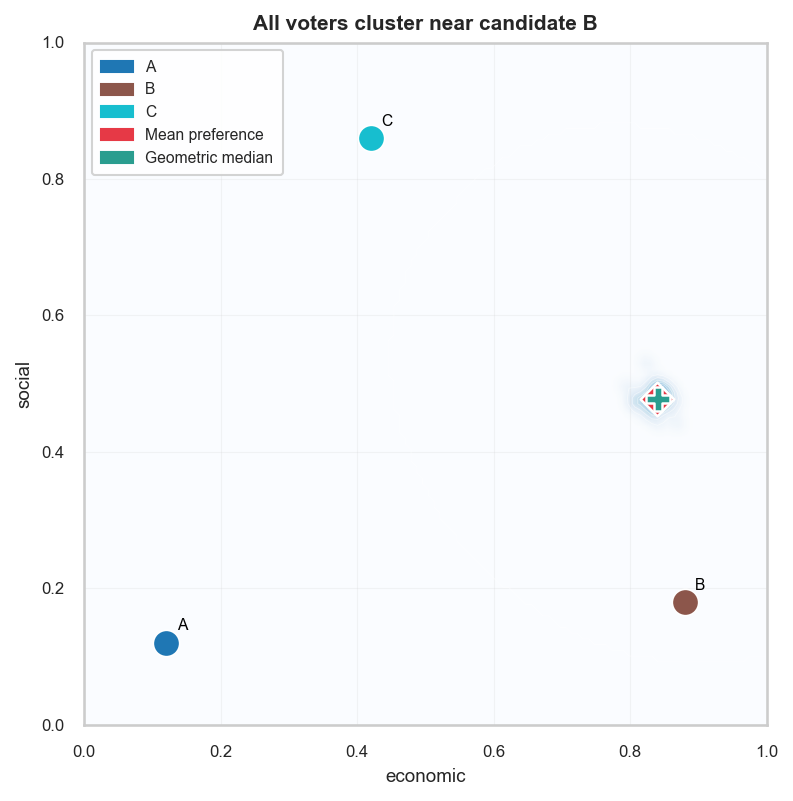

In [4]:
unanimity_electorate, unanimity_candidates, unanimity_ballots = make_unanimity_violation_profile()
unanimity_ranking, unanimity_table = criterion_table(
    unanimity_ballots,
    unanimity_candidates,
    fixed_priority_ranking,
)

plot_electorate(
    unanimity_electorate,
    unanimity_candidates,
    title="All voters cluster near candidate B",
)

display(
    pd.DataFrame(
        {
            "item": ["shared voter ranking", "social ranking produced by the rule"],
            "value": [
                ranking_text([unanimity_candidates.labels[idx] for idx in unanimity_ballots.rankings[0]]),
                ranking_text(unanimity_ranking.ordered_labels),
            ],
        }
    )
)
display(unanimity_table)

This example is useful because the failure is very direct. The voters all agree that B should be above A, but the rule still ranks A above B.
So this case gives up unanimity. At the same time, it does not fail because one voter is secretly controlling the outcome, and on this profile it does not show an IIA problem. 

---
## Case study 2: Non-dictatorship failure

The second rule is dictatorship in the sense: it simply copies voter 0's ranking and uses that as the social ranking.

The electorate below is mixed enough that there is no unanimous agreement to hide behind. The point of the example is just to see what a direct failure of non-dictatorship looks like.

,item,value
0,voter 0 ranking,A > B > C
1,social ranking produced by the rule,A > B > C


,criterion,satisfied_on_this_profile,note
0,Unanimity,True,There are no unanimous pairwise voter preferen...
1,Non-dictatorship,False,Fails on this profile: the social ranking exac...
2,IIA,True,No IIA violations were found in the searched c...


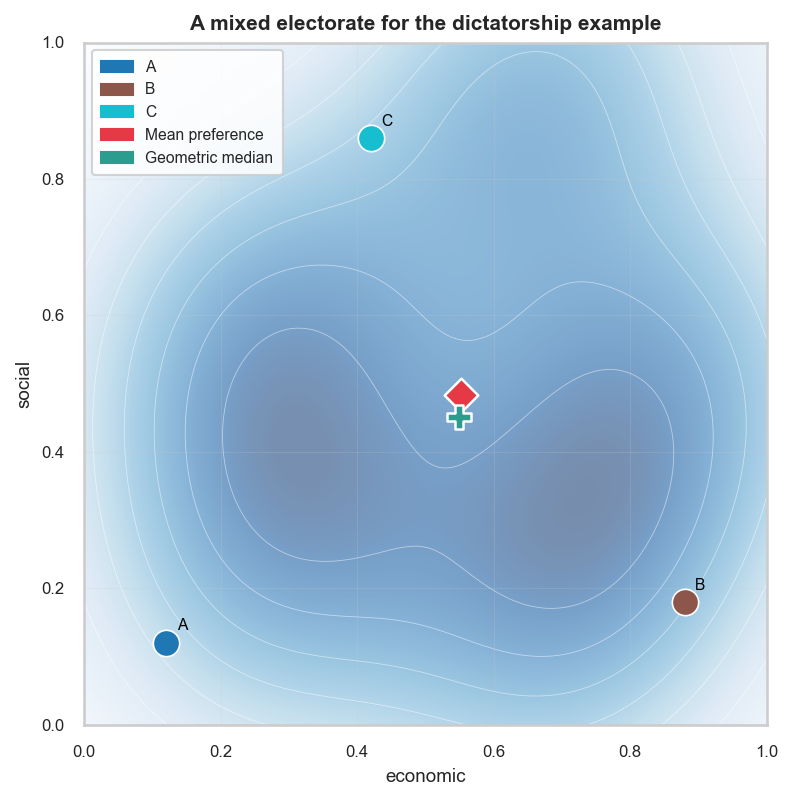

In [5]:
dictator_electorate, dictator_candidates, dictator_ballots = make_dictatorship_profile()
dictator_ranking, dictator_table = criterion_table(
    dictator_ballots,
    dictator_candidates,
    dictatorship_rule,
)

plot_electorate(
    dictator_electorate,
    dictator_candidates,
    title="A mixed electorate for the dictatorship example",
)

display(
    pd.DataFrame(
        {
            "item": ["voter 0 ranking", "social ranking produced by the rule"],
            "value": [
                ranking_text([dictator_candidates.labels[idx] for idx in dictator_ballots.rankings[0]]),
                ranking_text(dictator_ranking.ordered_labels),
            ],
        }
    )
)
display(dictator_table)

Here the rule does not ignore the voters. Instead, it listens to only one of them. That means non-dictatorship fails immediately. But this is also what makes the example useful: it helps separate non-dictatorship from the other conditions. On this profile, the rule does not create a unanimity violation, and it does not create an IIA violation either. 

---
## Case study 3: IIA failure

The third rule is more interesting because it is not obviously absurd. It uses the Borda count, which many people find fairly reasonable when they first meet it. The electorate here is chosen so that Borda changes its social view of A versus B when candidate C is removed. The voters themselves do not change between the two versions of the example. Only the candidate set changes.

,setting,social ranking,social view of A vs B
0,"with A, B, C",C > B > A,B above A
1,with only A and B,A > B,A above B


,criterion,satisfied_on_this_profile,note
0,Unanimity,True,The social ranking respects every unanimous pa...
1,Non-dictatorship,True,No active voter's full pairwise ordering match...
2,IIA,False,Removing other candidates changes at least one...


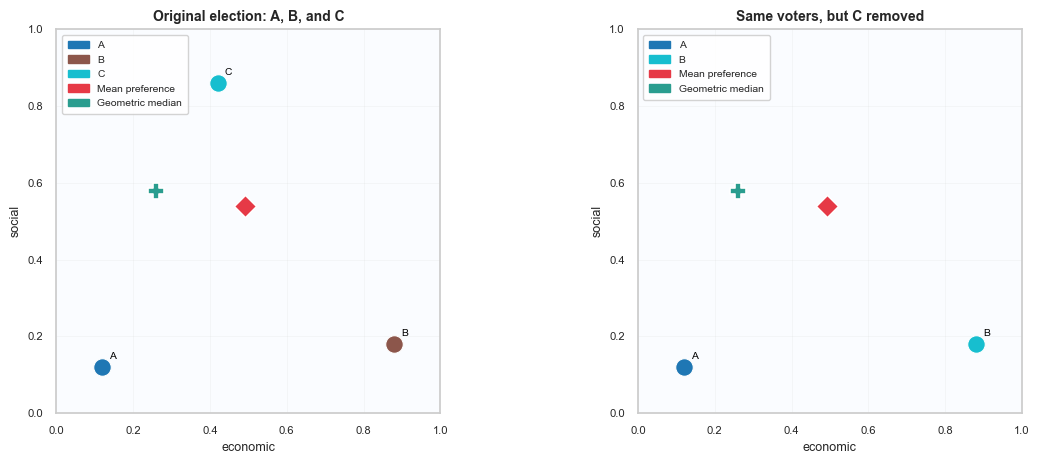

In [6]:
iia_electorate, iia_candidates, iia_ballots = make_iia_profile()
iia_ranking, iia_table = criterion_table(
    iia_ballots,
    iia_candidates,
    borda_social_ranking,
)
iia_comparison = compare_iia(
    ballots=iia_ballots,
    ranking_builder=borda_social_ranking,
    candidate_a=0,
    candidate_b=1,
    removed_candidates=[2],
    candidates=iia_candidates,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_electorate(
    iia_electorate,
    iia_candidates,
    title="Original election: A, B, and C",
    ax=axes[0],
)
plot_electorate(
    iia_electorate,
    iia_candidates.subset([0, 1]),
    title="Same voters, but C removed",
    ax=axes[1],
)
plt.tight_layout()

display(
    pd.DataFrame(
        {
            "setting": ["with A, B, C", "with only A and B"],
            "social ranking": [
                ranking_text(iia_comparison.full_ranking.ordered_labels),
                ranking_text(iia_comparison.restricted_ranking.ordered_labels),
            ],
            "social view of A vs B": [
                "A above B" if iia_comparison.full_preference else "B above A",
                "A above B" if iia_comparison.restricted_preference else "B above A",
            ],
        }
    )
)
display(iia_table)

Here Borda is not failing because it ignores the voters, and it is not failing because one voter controls the outcome. Instead, it fails because the social choice between A and B depends on whether C is present. On this profile, unanimity is not the problem and non-dictatorship is not the problem either. 

---
## A practical extension of case study 3: Spoiler effect

This next example is closer to the language used in everyday politics. There are two candidates in the left lane and one candidate in the right lane. With all three candidates present, the left vote splits. That lets the right candidate rank above the main left candidate under plurality. But once the spoiler candidate is removed, the left candidate jumps above the right candidate.


,setting,social ranking,social view of Left vs Right
0,"with Left, Right, and Left-Spoiler",Right > Left > Left-Spoiler,Right above Left
1,with only Left and Right,Left > Right,Left above Right


,criterion,satisfied_on_this_profile,note
0,Unanimity,True,There are no unanimous pairwise voter preferen...
1,Non-dictatorship,True,No active voter's full pairwise ordering match...
2,IIA,False,Removing other candidates changes at least one...


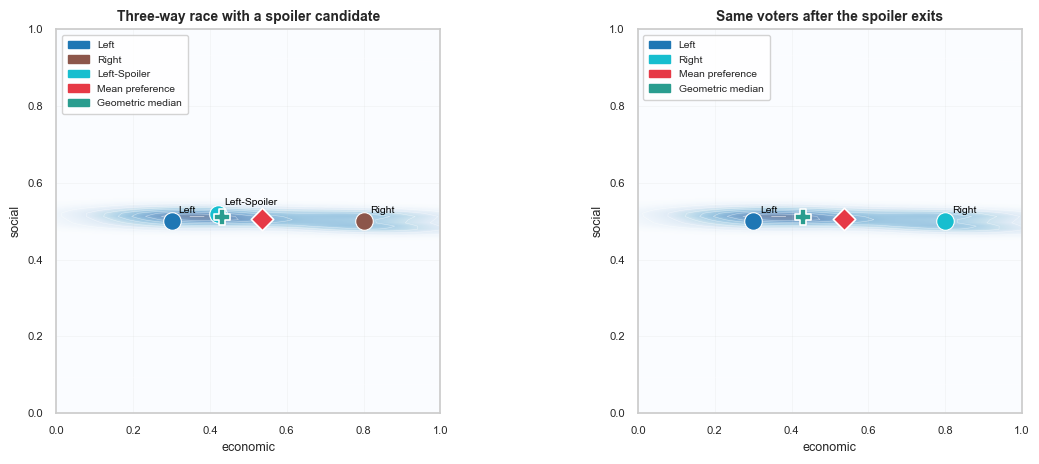

In [7]:
spoiler_electorate, spoiler_candidates, spoiler_ballots = make_plurality_spoiler_profile()
spoiler_ranking, spoiler_table = criterion_table(
    spoiler_ballots,
    spoiler_candidates,
    plurality_social_ranking,
)
spoiler_comparison = compare_iia(
    ballots=spoiler_ballots,
    ranking_builder=plurality_social_ranking,
    candidate_a=0,
    candidate_b=1,
    removed_candidates=[2],
    candidates=spoiler_candidates,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_electorate(
    spoiler_electorate,
    spoiler_candidates,
    title="Three-way race with a spoiler candidate",
    ax=axes[0],
)
plot_electorate(
    spoiler_electorate,
    spoiler_candidates.subset([0, 1]),
    title="Same voters after the spoiler exits",
    ax=axes[1],
)
plt.tight_layout()

display(
    pd.DataFrame(
        {
            "setting": ["with Left, Right, and Left-Spoiler", "with only Left and Right"],
            "social ranking": [
                ranking_text(spoiler_comparison.full_ranking.ordered_labels),
                ranking_text(spoiler_comparison.restricted_ranking.ordered_labels),
            ],
            "social view of Left vs Right": [
                "Left above Right" if spoiler_comparison.full_preference else "Right above Left",
                "Left above Right" if spoiler_comparison.restricted_preference else "Right above Left",
            ],
        }
    )
)
display(spoiler_table)

---
## Takeaway and final case study

Taken together, the case studies show a few different faces of Arrow-style impossibility. However, what the theorem does not mean is that democracy itself is futile. The simulation below illustrates how one can still get a fairly reasonable result even if, technically, one of the three conditions is violated.

,item,value
0,Borda ranking in the full election,Center > Center-Left > Left > Right
1,winner in the full election,Center
2,A vs Center after Right exits,Left above Center


,criterion,satisfied_on_this_profile,note
0,Unanimity,True,There are no unanimous pairwise voter preferen...
1,Non-dictatorship,True,No active voter's full pairwise ordering match...
2,IIA,False,Removing other candidates changes at least one...


,candidate,distance_to_voter_mean
0,Center,0.117
1,Center-Left,0.119
2,Left,0.203
3,Right,0.437


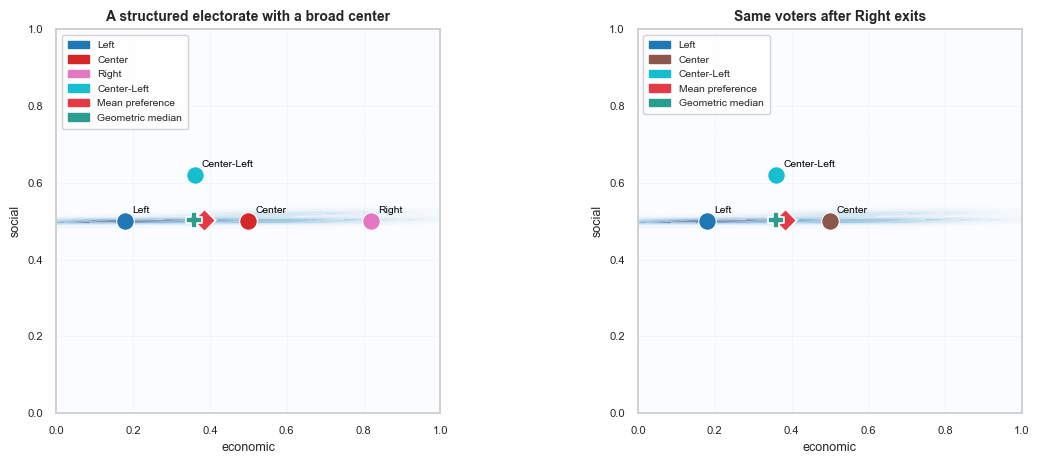

In [8]:
reasonable_electorate, reasonable_candidates, reasonable_ballots = make_reasonable_borda_profile()
reasonable_ranking, reasonable_table = criterion_table(
    reasonable_ballots,
    reasonable_candidates,
    borda_social_ranking,
)
reasonable_comparison = compare_iia(
    ballots=reasonable_ballots,
    ranking_builder=borda_social_ranking,
    candidate_a=0,
    candidate_b=1,
    removed_candidates=[2],
    candidates=reasonable_candidates,
)

voter_mean = reasonable_electorate.mean()
distance_table = pd.DataFrame(
    {
        "candidate": reasonable_candidates.labels,
        "distance_to_voter_mean": np.linalg.norm(
            reasonable_candidates.positions - voter_mean,
            axis=1,
        ),
    }
).sort_values("distance_to_voter_mean").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_electorate(
    reasonable_electorate,
    reasonable_candidates,
    title="A structured electorate with a broad center",
    ax=axes[0],
)
plot_electorate(
    reasonable_electorate,
    reasonable_candidates.subset([0, 1, 3]),
    title="Same voters after Right exits",
    ax=axes[1],
)
plt.tight_layout()

display(
    pd.DataFrame(
        {
            "item": [
                "Borda ranking in the full election",
                "winner in the full election",
                "A vs Center after Right exits",
            ],
            "value": [
                ranking_text(reasonable_ranking.ordered_labels),
                reasonable_ranking.ordered_labels[0],
                (
                    "Left above Center"
                    if reasonable_comparison.restricted_preference
                    else "Center above Left"
                ),
            ],
        }
    )
)
display(reasonable_table)
display(distance_table)

This final example is useful because it makes the theorem easier to interpret in a practical way. Borda technically fails IIA on this profile: once the Right candidate exits, the social ordering between Left and Center flips. But the full-election result still looks fairly reasonable. The winner is **Center**, and the distance table shows that Center is essentially the most central candidate in the field by voter mean distance. So the lesson is not that any violation of an Arrow criterion makes a rule useless. A rule can still produce a sensible-looking outcome in a particular election even though, in a technical sense, one of the criteria fails.

Original paper: Arrow, K. J. (1950). A difficulty in the concept of social welfare. Journal of Political Economy, 58(4), 328-346.